Logistic Regression for Admission ..
Last Updated: February 16th, 2025

Daily Challenge: Logistic Regression for Admission Prediction

What you will learn
Data visualization with scatter plots.
Basic understanding of logistic regression.
Applying a logistic regression model to binary classification.
Interpreting the results of logistic regression.


What you will create
You will create a logistic regression model that uses examination scores to predict university admission.
dataset available here



Your Task
Data Exploration: Load and visualize the data.

Use pandas to load the dataset and examine the first few rows.
Create a scatter plot to visualize the data points for students who were admitted versus those who were not based on their exam scores.
Applying Logistic Regression with scikit-learn:

Implement logistic regression using the LogisticRegression function from scikit-learn to find the best parameters for your model.
Train the logistic regression model on your dataset.
Making Predictions:

Use the trained logistic regression model to make predictions on your dataset.
Calculate the accuracy of your model.
Model Evaluation:

Interpret the result of logistic regression and the accuracy of your model.

Duration & Difficulty
Duration (approx)	Difficulty
60 minutes	⭐⭐
Submit your Daily Challenge
Don’t forget to push your Jupyter Notebook or Python script to GitHub and share it in your network.

In [ ]:
!pip install scikit-learn

In [48]:
# IMPORTS GLOBAUX
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import norm, f_oneway, binom, pearsonr, spearmanr
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
import scipy.linalg as la
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics import confusion_matrix



In [6]:
df = pd.read_csv("C:\\Users\\cibei\\Desktop\\PSTB_GenAI\\WEEK5\\DAY2\\DailyChallenge\\ex2data1(1).txt")

In [13]:
df = pd.read_csv("C:\\Users\\cibei\\Desktop\\PSTB_GenAI\\WEEK5\\DAY2\\DailyChallenge\\ex2data1(1).txt", header=None, names=["Exam 1", "Exam 2", "Admitted"])


In [14]:
print(df.columns)

Index(['Exam 1', 'Exam 2', 'Admitted'], dtype='object')


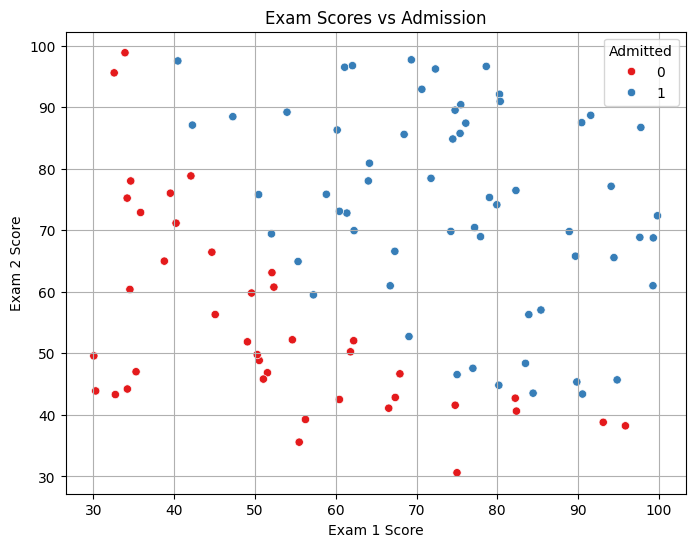

In [35]:
# Visualize the data
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x="Exam 1", y="Exam 2", hue="Admitted", palette="Set1")
plt.title("Exam Scores vs Admission")
plt.xlabel("Exam 1 Score")
plt.ylabel("Exam 2 Score")
plt.grid(True)
plt.show()

C:\Users\cibei\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


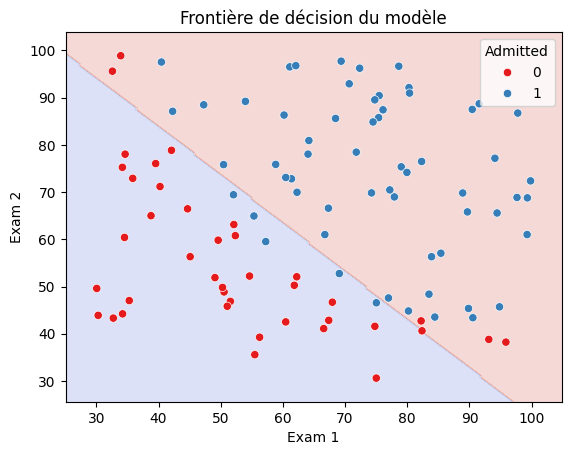

In [36]:
# Peut-on tracer une frontière de décision ?

# Création d'une grille de points
x_min, x_max = df["Exam 1"].min() - 5, df["Exam 1"].max() + 5
y_min, y_max = df["Exam 2"].min() - 5, df["Exam 2"].max() + 5
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                     np.linspace(y_min, y_max, 200))
grid = np.c_[xx.ravel(), yy.ravel()]
Z = model.predict(grid).reshape(xx.shape)

# Affichage
plt.contourf(xx, yy, Z, alpha=0.2, cmap='coolwarm')
sns.scatterplot(data=df, x="Exam 1", y="Exam 2", hue="Admitted", palette="Set1")
plt.title("Frontière de décision du modèle")
plt.show()

# INTERPRETATION DU SCATTER PLOT 

# Que représente chaque axe de votre graphique ? 
    => ADMISSION à l'Examen 1 (x). ADMISSION à l'Examen 2 (y).
# Que signifie la couleur (ou la forme) des points ? La légende est-elle claire ? 
OUI. BLEU = Admis. ROUGE = Recalé. 
# En observant le graphique, une séparation claire entre les deux groupes (admis/non-admis) est-elle visible ? Existe-t-il une "frontière" évidente ? 
OUI. Elle est bien mise en évidence ci-dessus.
# Qu'est-ce que cette visualisation suggère sur la difficulté du problème ? 
Un nombre significatif de candidats a échoué, malgré une notation > 50 à l'un des deux examens. En revanche, près de 100% des admis ont une notation moyenne > 50. 
# Pensez-vous qu'un modèle linéaire simple (comme la régression logistique) pourrait être efficace ? Justifiez votre hypothèse.
La régression logistique est appropriée ici. En effet : 
    La séparation entre admis / non-admis est globalement linéaire.
    Le graphique montre une tendance diagonale claire.
    Les erreurs (faux positifs/faux négatifs) sont rares et localisées.
    Le modèle est simple, rapide, et facilement interprétable.





In [37]:
# Quelles sont les corrélations entre les variables ?
df.corr()


,Exam 1,Exam 2,Admitted
Exam 1,1.000000,-0.023665,0.574057
Exam 2,-0.023665,1.000000,0.512323
Admitted,0.574057,0.512323,1.000000


<Axes: >

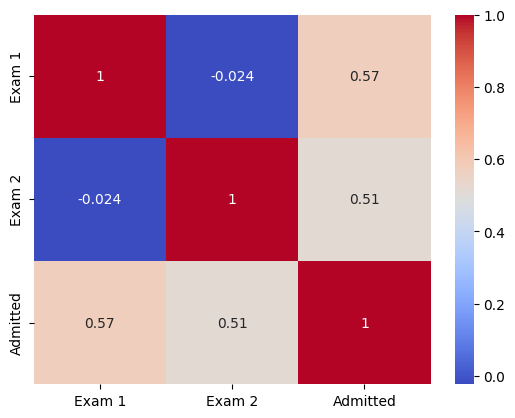

In [38]:
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")

In [ ]:
# Peut-on détecter les cas ambigus ?
# Avec predict_proba :
model.predict_proba([[60, 70]])


In [39]:
# Peut-on classer automatiquement sans visualisation ?
new_data = [[60, 70]]  # exemple
prediction = model.predict(new_data)
print("Admis" if prediction[0] == 1 else "Non admis")

Admis


C:\Users\cibei\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Exam 1    100 non-null    float64
 1   Exam 2    100 non-null    float64
 2   Admitted  100 non-null    int64  
dtypes: float64(2), int64(1)
memory usage: 2.5 KB


In [16]:
df.head()

,Exam 1,Exam 2,Admitted
0,34.623660,78.024693,0
1,30.286711,43.894998,0
2,35.847409,72.902198,0
3,60.182599,86.308552,1
4,79.032736,75.344376,1


In [18]:
df.tail()


,Exam 1,Exam 2,Admitted
95,83.489163,48.380286,1
96,42.261701,87.103851,1
97,99.315009,68.775409,1
98,55.340018,64.931938,1
99,74.775893,89.529813,1


In [19]:
# Prepare data
X = df[["Exam 1", "Exam 2"]]
y = df["Admitted"]


In [20]:
# Train logistic regression model
model = LogisticRegression()
model.fit(X, y)



,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [21]:
# Make predictions
predictions = model.predict(X)

In [25]:
# Make probability (pour aller un peu plus loin) :
proba = model.predict_proba(X)

In [22]:
# Calculate accuracy
accuracy = accuracy_score(y, predictions)
report = classification_report(y, predictions, output_dict=True)

In [29]:
print(f"Accuracy: {accuracy:.2f}")
print("Accuracy :", accuracy_score(y, predictions))

Accuracy: 0.89
Accuracy : 0.89


In [30]:
print(classification_report(y, predictions))

              precision    recall  f1-score   support

           0       0.87      0.85      0.86        40
           1       0.90      0.92      0.91        60

    accuracy                           0.89       100
   macro avg       0.89      0.88      0.88       100
weighted avg       0.89      0.89      0.89       100



In [45]:
# Préparer X et y
X = df[["Exam 1", "Exam 2"]]
y = df["Admitted"]

# Entraîner le modèle
model = LogisticRegression()
model.fit(X, y)

# Prédictions sur tout le jeu de données
y_pred = model.predict(X)

# Afficher les 10 premières valeurs réelles vs prédites
comparison = pd.DataFrame({"Réel": y.values[:10], "Prédit": y_pred[:10]})
comparison

,Réel,Prédit
0,0,0
1,0,0
2,0,0
3,1,1
4,1,1
5,0,0
6,1,1
7,1,0
8,1,1
9,1,1


In [49]:
errors[["Exam 1", "Exam 2", "Admitted", "Prédit"]].head(10)

,Exam 1,Exam 2,Admitted,Prédit
7,75.024746,46.554014,1,0
10,95.861555,38.225278,0,1
16,69.070144,52.740470,1,0
27,93.114389,38.800670,0,1
33,52.045405,69.432860,1,0
36,33.915500,98.869436,0,1
43,82.368754,40.618255,0,1
57,32.577200,95.598548,0,1
79,82.226662,42.719879,0,1
83,57.238706,59.514282,1,0


Coefficients appris :
Exam 1 : 0.2054
Exam 2 : 0.2006
Intercept : -25.0522

🔍 Étudiants mal classés (extrait) :
       Exam 1     Exam 2  Admitted  Prédit
7   75.024746  46.554014         1       0
10  95.861555  38.225278         0       1
16  69.070144  52.740470         1       0
27  93.114389  38.800670         0       1
33  52.045405  69.432860         1       0
36  33.915500  98.869436         0       1
43  82.368754  40.618255         0       1
57  32.577200  95.598548         0       1
79  82.226662  42.719879         0       1
83  57.238706  59.514282         1       0


C:\Users\cibei\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


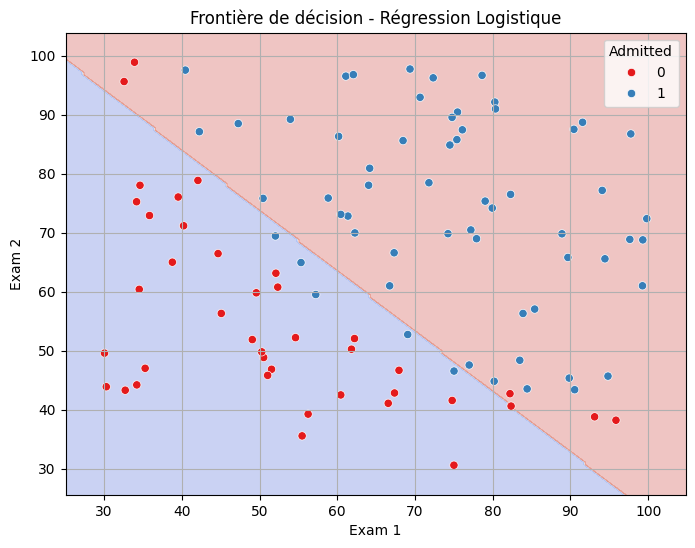

In [51]:
# Analyse des coefficients
print("Coefficients appris :")
for var, coef in zip(X.columns, model.coef_[0]):
    print(f"{var} : {coef:.4f}")
print(f"Intercept : {model.intercept_[0]:.4f}")

# Étudiants mal classés
erreurs = df[df["Admitted"] != df["Prédit"]]
print("\n🔍 Étudiants mal classés (extrait) :")
print(erreurs[["Exam 1", "Exam 2", "Admitted", "Prédit"]].head(10))

# Frontière de décision
x_min, x_max = X["Exam 1"].min() - 5, X["Exam 1"].max() + 5
y_min, y_max = X["Exam 2"].min() - 5, X["Exam 2"].max() + 5
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                     np.linspace(y_min, y_max, 200))
grid = np.c_[xx.ravel(), yy.ravel()]
Z = model.predict(grid).reshape(xx.shape)

plt.figure(figsize=(8, 6))
plt.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')
sns.scatterplot(data=df, x="Exam 1", y="Exam 2", hue="Admitted", palette="Set1")
plt.title("Frontière de décision - Régression Logistique")
plt.xlabel("Exam 1")
plt.ylabel("Exam 2")
plt.grid(True)
plt.show()

In [23]:
accuracy, report

(0.89,
 {'0': {'precision': 0.8717948717948718,
   'recall': 0.85,
   'f1-score': 0.8607594936708861,
   'support': 40.0},
  '1': {'precision': 0.9016393442622951,
   'recall': 0.9166666666666666,
   'f1-score': 0.9090909090909091,
   'support': 60.0},
  'accuracy': 0.89,
  'macro avg': {'precision': 0.8867171080285834,
   'recall': 0.8833333333333333,
   'f1-score': 0.8849252013808976,
   'support': 100.0},
  'weighted avg': {'precision': 0.8897015552753258,
   'recall': 0.89,
   'f1-score': 0.8897583429228999,
   'support': 100.0}})

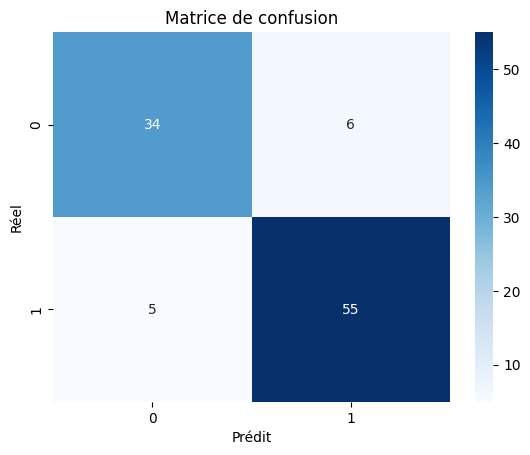

In [34]:
conf_matrix = confusion_matrix(y, predictions)
sns.heatmap(conf_matrix, annot=True, cmap="Blues", fmt='d')
plt.xlabel("Prédit")
plt.ylabel("Réel")
plt.title("Matrice de confusion")
plt.show()

# •	Model Evaluation:
    # Interpret the result of logistic regression and the accuracy of your model.


# accuracy = 0.89 - Cela signifie que 89 % des prédictions sont correctes.
Si on avait 100 exemples :
    89 ont été bien classés
    11 se sont trompés

# Détail par classe ('0' et '1')
    '0' = par exemple « non admis »
    '1' = par exemple « admis »

# Pour chaque classe, on a 4 indicateurs importants :
🔹 Pour la classe '0' :
        'precision': 0.87
            Sur toutes les fois où le modèle a prévu “0”, il avait raison 87 % du temps.
        'recall': 0.85
            Parmi les vrais “0”, il a réussi à en retrouver 85 %.
        'f1-score': 0.86
            Moyenne entre precision et recall. C’est un bon indicateur global pour cette classe.
        'support': 40
            Il y avait 40 vrais exemples dans cette classe.
🔹 Pour la classe '1' :
        'precision': 0.90
            Quand le modèle dit “1”, il a raison dans 90 % des cas.
        'recall': 0.92
            Il détecte bien les “1”, il les retrouve dans 91.6 % des cas.
        'f1-score': 0.91
            Moyenne globale entre précision et rappel. Très bon score !
        'support': 60
            Il y avait 60 vrais “1” dans le jeu de test.

# Moyennes globales
Ces lignes donnent des résumés globaux :

# macro avg (moyenne non pondérée)
        'precision': 88.7 %
        'recall': 88.3 %
        'f1-score': 88.5 %
Nota : Chaque classe compte autant, même si l’une est plus fréquente. Utile pour vérifier si une classe est oubliée par le modèle.

# weighted avg (moyenne pondérée)
        'precision': 88.9 %
        'recall': 89.0 %
        'f1-score': 88.9 %
Nota : Chaque classe compte en fonction de son nombre d’exemples (support). C’est souvent le score le plus représentatif globalement.

# Pour conclure :
    1. Le modèle fonctionne bien (89 % de bonnes réponses) ✅
    2. Il est un peu meilleur pour la classe 1 que la classe 0
    3. Il est équilibré, pas trop biaisé vers une classe
    4. Tous les indicateurs sont au-dessus de 85 %, ce qui est bon.

# CONSEILS & RECOMMANDATIONS POUR LA CONDUITE DE CE DAILY CHALLENGE (voir ci-dessous)
Clara Martinez
  14 h 45


:cercle_rouge: Aide et consignes supplémentaires pour le Daily Challenge d'aujourd'hui :
Phase 1 : Exploration et Visualisation des Données
L'objectif de cette phase n'est pas seulement de charger les données, mais de les "rencontrer". Vous devez comprendre leur structure, leur contenu et leurs limites avant même d'envisager un modèle.
1. Chargement et Examen Initial des Données
Consigne : Utilisez pandas pour charger le jeu de données et inspectez-le pour en comprendre la structure fondamentale.
Questions pour guider votre rédaction :
Quelles sont les dimensions du jeu de données (nombre de lignes et de colonnes) ?
Quelles sont les colonnes présentes et quel est leur type (numérique, catégoriel) ? Y a-t-il des données qui semblent mal formatées ?
Y a-t-il des valeurs manquantes ? Si oui, comment comptez-vous les gérer et pourquoi cette approche est-elle appropriée ?
Quelles sont les statistiques descriptives de base (moyenne, écart-type, min, max) pour les notes d'examen ? Que vous apprennent-elles sur la distribution des scores ?
2. Visualisation des Relations
Consigne : Créez un nuage de points (scatter plot) pour visualiser la répartition des étudiants (admis vs. non-admis) en fonction de leurs notes d'examen.
Questions pour guider votre rédaction :
Que représente chaque axe de votre graphique ? Que signifie la couleur (ou la forme) des points ? La légende est-elle claire ?
En observant le graphique, une séparation claire entre les deux groupes (admis/non-admis) est-elle visible ? Existe-t-il une "frontière" évidente ?
Qu'est-ce que cette visualisation suggère sur la difficulté du problème ? Pensez-vous qu'un modèle linéaire simple (comme la régression logistique) pourrait être efficace ? Justifiez votre hypothèse.
Phase 2 : Application de la Régression Logistique avec scikit-learn
Maintenant que vous avez une intuition visuelle, vous allez la formaliser mathématiquement.
3. Construction et Entraînement du Modèle
Consigne : La visualisation suggère qu'une frontière de décision pourrait séparer les étudiants. Implémentez un modèle de régression logistique avec scikit-learn pour trouver les paramètres optimaux de cette frontière, puis entraînez-le sur vos données.
Questions pour guider votre rédaction :
Pourquoi la régression logistique est-elle un choix de modèle approprié pour ce type de problème (classification binaire) ? Quelles sont ses hypothèses fondamentales ?
Qu'est-ce que le modèle "apprend" concrètement pendant la phase d'entraînement ? (Indice : il ne s'agit pas juste d'appuyer sur .fit()).
Quelles sont les variables que vous utilisez comme features (X) et quelle est la variable cible (y) ?
Phase 3 : Prédictions et Évaluation Quantitative
Le modèle est entraîné. Il est temps de l'utiliser et de mesurer sa performance brute.
4. Application du Modèle pour la Prédiction
Consigne : Utilisez votre modèle entraîné pour prédire le statut d'admission pour l'ensemble de votre jeu de données.
Questions pour guider votre rédaction :
Comment le modèle décide-t-il si un étudiant est "admis" (1) ou "non-admis" (0) à partir des scores d'examen ? Quel est le seuil de décision par défaut et que représente-t-il ?
Affichez côte à côte les 10 premières valeurs réelles et les 10 premières valeurs prédites. Le modèle semble-t-il correct à première vue ?
5. Première Évaluation : Calcul de l'Accuracy
Consigne : Calculez le score de précision globale (accuracy) de votre modèle.
Questions pour guider votre rédaction :
Que représente exactement ce score en une phrase simple ?
Si l'accuracy est de 89%, cela signifie que le modèle a correctement classé 89% des étudiants. Est-ce un bon score ? Pourquoi ou pourquoi pas ? Quelles informations ce score unique ne vous donne-t-il pas ? (Par exemple, est-ce qu'il se trompe plus sur les admis ou les non-admis ?)
Phase 4 : Interprétation Approfondie et Évaluation Critique du Modèle
C'est l'étape la plus importante. Un chiffre ne suffit pas ; il faut comprendre le "comment" et le "pourquoi" derrière la performance du modèle.
6. Interprétation des Résultats et du Modèle
Consigne : Allez au-delà de l'accuracy pour interpréter ce que votre modèle a appris et quelles sont ses implications.
Questions pour guider votre rédaction :
Analyse des coefficients : Quels sont les coefficients (ou "poids") que le modèle a appris pour chaque note d'examen ? Que signifie un coefficient positif ? Comment une augmentation d'un point à un examen influence-t-elle la probabilité (ou le log-odds) d'admission selon votre modèle ?
Visualisation de la frontière : Pouvez-vous superposer la frontière de décision apprise par le modèle sur votre nuage de points initial ? Que vous montre cette visualisation sur les zones où le modèle est performant et celles où il échoue ?
Limites et cas d'erreur : Identifiez un ou deux exemples d'étudiants que le modèle a mal classés. En regardant leurs scores, pourquoi pensez-vous que le modèle s'est trompé ? Quelles sont les limites inhérentes à un modèle qui ne se base que sur deux notes d'examen ? Quelles autres données pourraient l'améliorer ?
Conclusion globale : En résumé, votre modèle est-il fiable ? Dans quel contexte pourriez-vous le recommander, et quelles mises en garde donneriez-vous à quelqu'un qui voudrait l'utiliser pour prendre une décision réelle ?